**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
**Proyecto: Análisis Exploratorio y Técnicas Avanzadas de Preprocesamiento de Datos**  
*Caso de Estudio: Base de Datos de Cáncer de Mama de Wisconsin (WBCD)*

---

## 1. Introducción y Marco Teórico

El cáncer de mama es una de las principales neoplasias malignas diagnosticadas a nivel global. En la práctica oncológica y patológica moderna, la **Biopsia por Aspiración con Aguja Fina (BAAF / FNA - Fine Needle Aspiration)** constituye un procedimiento diagnóstico mínimamente invasivo fundamental para evaluar nódulos y masas mamarias sospechosas. Durante la BAAF, se extraen muestras celulares que se observan al microscopio óptico para evaluar alteraciones morfológicas nucleares y citoplasmáticas asociadas a malignidad.

El conjunto de datos **Wisconsin Breast Cancer Database (WBCD)** fue recolectado en los Hospitales de la Universidad de Wisconsin, Madison, por el **Dr. William H. Wolberg** (Wolberg & Mangasarian, 1990). Este dataset sintetiza 9 características citológicas cuantitativas medidas en una escala ordinal discreta de 1 a 10 (donde 1 representa una morfología normal/benigna y 10 una anomalía severa/maligna), acompañadas del diagnóstico histopatológico final (Benigno vs. Maligno).

### Objetivos del Proyecto:
1. **Análisis Exploratorio de Datos (EDA):** Caracterizar exhaustivamente las distribuciones univariadas, las relaciones bivariadas y las correlaciones multivariadas del espacio citológico.
2. **Limpieza de Datos:** Identificar y tratar valores ausentes (`?` en la variable *Bare Nuclei*) y registros duplicados mediante estrategias robustas de imputación condicionada.
3. **Extracción de Características (Feature Engineering):** Construir índices biomédicos compuestos que capturen la atipia celular y la agresividad proliferativa con mayor poder de discriminación diagnóstica.
4. **Aumento de Datos (Data Augmentation):** Mitigar el desbalance de clases inherente al muestreo clínico mediante sobremuestreo sintético controlado (**SMOTE**).
5. **Reducción de Dimensionalidad:** Proyectar el espacio de características de alta dimensionalidad hacia subespacios ortogonales latentes mediante **Análisis de Componentes Principales (PCA)**, evaluando la preservación de la varianza explicada y la separabilidad de conglomerados.
6. **Comparación Visual Rigurosa (Antes vs. Después):** Proporcionar contrastes gráficos directos para cada técnica de preprocesamiento aplicada con su debida interpretación científica y clínica.

---

## 2. Preparación del Entorno y Dependencias

En esta sección cargamos las librerías analíticas fundamentales de Python para manipulación tabular (`pandas`, `numpy`), visualización científica (`matplotlib`, `seaborn`), transformaciones de Machine Learning (`scikit-learn`) y aumento de datos (`imbalanced-learn`).

In [1]:
# Importación de librerías esenciales del sistema y análisis de datos
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de módulos específicos de Scikit-Learn e Imbalanced-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# Comprobación de versiones instaladas
print("numpy           :", np.__version__)
print("pandas          :", pd.__version__)
print("matplotlib      :", __import__("matplotlib").__version__)
print("seaborn         :", sns.__version__)
print("scikit-learn    :", __import__("sklearn").__version__)
print("imbalanced-learn:", __import__("imblearn").__version__)

numpy           : 2.3.3
pandas          : 2.3.3
matplotlib      : 3.10.7
seaborn         : 0.13.2
scikit-learn    : 1.7.2
imbalanced-learn: 0.14.2


Configuración de la paleta cromática corporativa del curso para garantizar consistencia visual en todas las figuras, formatos numéricos y estilos de presentación.

In [2]:
# Definición de la paleta de colores institucional del curso
AZUL_OSCURO = "#112057"
AZUL        = "#7697CD"
AZUL_CLARO  = "#BFD5EA"
ROJO        = "#C02B2B"

# Configuración del tema y estilo de Seaborn y Matplotlib
sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

# Configuración de visualización en Pandas (2 decimales fijos)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

---

## 3. Carga y Estructura del Dataset

### Diccionario de Variables Citológicas:
El dataset cuenta con 11 columnas. La primera corresponde al identificador del paciente (`Sample_Code_Number`), las siguientes 9 corresponden a descriptores cuantitativos de las células observadas al microscopio (escala 1 a 10), y la última representa la etiqueta diagnóstica (`Class`):

1. **`Sample_Code_Number`**: Código identificador de la muestra clínica.
2. **`Clump_Thickness`**: Grosor del grupo celular (evalúa si las células forman monocapas benignas o cúmulos tridimensionales gruesos).
3. **`Uniformity_Cell_Size`**: Uniformidad en el tamaño celular (la variación de tamaño o anisocitosis es indicativa de neoplasia).
4. **`Uniformity_Cell_Shape`**: Uniformidad de la forma nuclear/celular (el pleomorfismo nuclear caracteriza a las células cancerosas).
5. **`Marginal_Adhesion`**: Pérdida de adhesión marginal (las células normales se adhieren fuertemente; las tumorales pierden cohesión para migrar).
6. **`Single_Epithelial_Cell_Size`**: Tamaño de la célula epitelial única (células epiteliales anormalmente grandes denotan malignidad).
7. **`Bare_Nuclei`**: Núcleos desnudos (núcleos sin citoplasma circundante, signo de alta pérdida de membrana celular en malignidad).
8. **`Bland_Chromatin`**: Textura de la cromatina (cromatina fina/uniforme en células normales vs. cromatina condensada/grumosa en células tumorales).
9. **`Normal_Nucleoli`**: Nucléolos normales (visibilidad de nucléolos agrandados y prominentes en células en rápida proliferación).
10. **`Mitoses`**: Tasa de actividad mitótica (células observadas en división celular activa).
11. **`Class`**: Diagnóstico patológico (**`2 = Benigno`**, **`4 = Maligno`**).

In [3]:
# Definición de los nombres de columnas oficiales según la documentación técnica
columnas = [
    "Sample_Code_Number",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

# Definición de la ruta del archivo con soporte para entorno local y repositorio Git
ruta_datos = "breast-cancer-wisconsin.data"
if not os.path.exists(ruta_datos):
    posibles_rutas = [
        r"C:\Users\ruben\OneDrive\Desktop\Notebook Preprocesamiento\breast-cancer-wisconsin.data",
        os.path.join(os.getcwd(), "breast-cancer-wisconsin.data"),
        os.path.join(os.getcwd(), "project", "Notebook Preprocesamiento", "breast-cancer-wisconsin.data")
    ]
    for r in posibles_rutas:
        if os.path.exists(r):
            ruta_datos = r
            break

# Carga del archivo CSV (sin encabezado original, especificando nombres de columnas)
df_raw = pd.read_csv(ruta_datos, names=columnas, header=None)

# Verificación de dimensiones
print("Dimensiones iniciales del dataset:", df_raw.shape[0], "registros x", df_raw.shape[1], "columnas")
print("Cumplimiento de volumen suficiente (>500 registros):", len(df_raw) >= 500)

# Visualización de los primeros 5 registros
df_raw.head(5)

Dimensiones iniciales del dataset: 699 registros x 11 columnas
Cumplimiento de volumen suficiente (>500 registros): True


,Sample_Code_Number,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


---

## 4. Análisis Exploratorio de Datos (EDA)

Examinamos la estructura interna, tipos de datos asignados automáticamente por Pandas y la presencia de caracteres atípicos.

In [4]:
# Revisamos los tipos de datos de cada columna
print("Tipos de datos detectados:")
print(df_raw.dtypes)

# Detectamos valores no numéricos en la columna Bare_Nuclei
valores_interrogacion = (df_raw["Bare_Nuclei"] == "?").sum()
print("\nTotal de valores faltantes codificados como '?' en Bare_Nuclei:", valores_interrogacion)

# Distribución inicial de la variable objetivo 'Class'
conteo_clases = df_raw["Class"].value_counts()
print("\nDistribución diagnóstica:")
print(f"Clase 2 (Benigno) : {conteo_clases.get(2, 0)} muestras ({conteo_clases.get(2, 0)/len(df_raw)*100:.2f}%)")
print(f"Clase 4 (Maligno) : {conteo_clases.get(4, 0)} muestras ({conteo_clases.get(4, 0)/len(df_raw)*100:.2f}%)")

Tipos de datos detectados:
Sample_Code_Number              int64
Clump_Thickness                 int64
Uniformity_Cell_Size            int64
Uniformity_Cell_Shape           int64
Marginal_Adhesion               int64
Single_Epithelial_Cell_Size     int64
Bare_Nuclei                    object
Bland_Chromatin                 int64
Normal_Nucleoli                 int64
Mitoses                         int64
Class                           int64
dtype: object

Total de valores faltantes codificados como '?' en Bare_Nuclei: 16

Distribución diagnóstica:
Clase 2 (Benigno) : 458 muestras (65.52%)
Clase 4 (Maligno) : 241 muestras (34.48%)


### 4.1. Análisis Univariado y Estadísticos Descriptivos

Para calcular los estadísticos descriptivos con precisión matemática, realizamos una conversión temporal de los valores `'?'` a `NaN` en `Bare_Nuclei` para que Pandas compute los momentos estadísticos sobre todas las 9 características citológicas.

In [5]:
# Lista de las 9 variables numéricas citológicas
variables_citologicas = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

# Creamos una copia temporal asegurando que Bare_Nuclei sea numérica para el EDA
df_eda_temp = df_raw.copy()
df_eda_temp["Bare_Nuclei"] = pd.to_numeric(df_eda_temp["Bare_Nuclei"], errors="coerce")
df_eda_temp["Diagnostico"] = df_eda_temp["Class"].map({2: "Benigno", 4: "Maligno"})

# Generación de la tabla de estadísticos descriptivos
tabla_stats = df_eda_temp[variables_citologicas].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
print("Tabla 1. Estadísticos Descriptivos de las Variables Citológicas (WBCD):")
tabla_stats

Tabla 1. Estadísticos Descriptivos de las Variables Citológicas (WBCD):


,count,mean,std,min,25%,50%,75%,max
Clump_Thickness,699.00,4.42,2.82,1.00,2.00,4.00,6.00,10.00
Uniformity_Cell_Size,699.00,3.13,3.05,1.00,1.00,1.00,5.00,10.00
Uniformity_Cell_Shape,699.00,3.21,2.97,1.00,1.00,1.00,5.00,10.00
Marginal_Adhesion,699.00,2.81,2.86,1.00,1.00,1.00,4.00,10.00
Single_Epithelial_Cell_Size,699.00,3.22,2.21,1.00,2.00,2.00,4.00,10.00
Bare_Nuclei,683.00,3.54,3.64,1.00,1.00,1.00,6.00,10.00
Bland_Chromatin,699.00,3.44,2.44,1.00,2.00,3.00,5.00,10.00
Normal_Nucleoli,699.00,2.87,3.05,1.00,1.00,1.00,4.00,10.00
Mitoses,699.00,1.59,1.72,1.00,1.00,1.00,1.00,10.00


Generamos la **Figura 1**, compuesta por dos paneles comparativos:
- **Figura 1A:** Distribución del *Grosor del Grupo Celular (Clump Thickness)* estratificada por diagnóstico.
- **Figura 1B:** Distribución de la *Uniformidad del Tamaño Celular (Uniformity of Cell Size)* estratificada por diagnóstico.

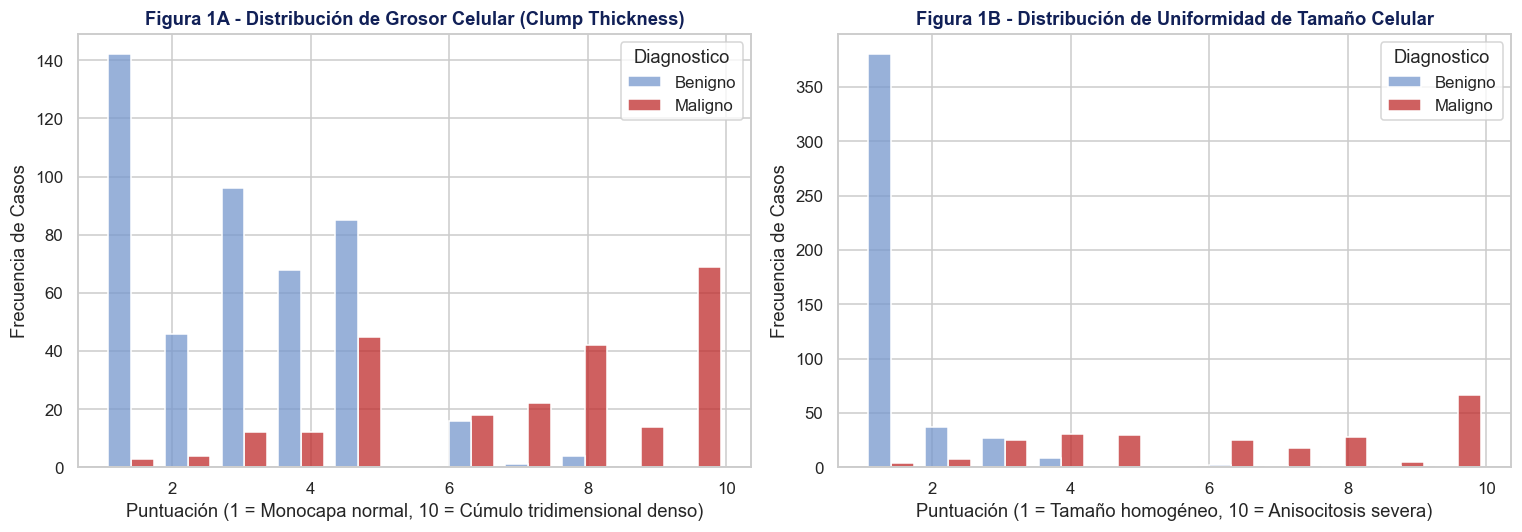

In [6]:
# Creamos una figura con dos subgráficos
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Figura 1A: Histograma de Clump Thickness por Diagnóstico
sns.histplot(
    data=df_eda_temp,
    x="Clump_Thickness",
    hue="Diagnostico",
    multiple="dodge",
    shrink=0.8,
    palette={"Benigno": AZUL, "Maligno": ROJO},
    ax=axs[0]
)
axs[0].set_title("Figura 1A - Distribución de Grosor Celular (Clump Thickness)")
axs[0].set_xlabel("Puntuación (1 = Monocapa normal, 10 = Cúmulo tridimensional denso)")
axs[0].set_ylabel("Frecuencia de Casos")

# Figura 1B: Histograma de Uniformity of Cell Size por Diagnóstico
sns.histplot(
    data=df_eda_temp,
    x="Uniformity_Cell_Size",
    hue="Diagnostico",
    multiple="dodge",
    shrink=0.8,
    palette={"Benigno": AZUL, "Maligno": ROJO},
    ax=axs[1]
)
axs[1].set_title("Figura 1B - Distribución de Uniformidad de Tamaño Celular")
axs[1].set_xlabel("Puntuación (1 = Tamaño homogéneo, 10 = Anisocitosis severa)")
axs[1].set_ylabel("Frecuencia de Casos")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Tabla 1 y Figura 1:**  
- **Tabla 1 (Estadísticos Descriptivos):** Revela una marcada asimetría positiva en la mayoría de los atributos citológicos. Variables como *Uniformity_Cell_Size* y *Mitoses* presentan medianas bajas ($50\% = 1.00$) pero con medias sensiblemente superiores ($3.13$ y $1.59$, respectivamente) debido a la presencia de tumores malignos que alcanzan puntuaciones máximas de $10$.
- **Figura 1A (Grosor Celular):** Los casos benignos (azul) se concentran predominantemente en puntuaciones entre 1 y 5 (mediana de 3), lo que refleja monocapas celulares delgadas y cohesión normal. Por el contrario, los casos malignos (rojo) exhiben una distribución marcadamente bimodal desplazada hacia puntuaciones de 6 a 10, correspondiente a la hiperplasia atípica y acumulación tridimensional multicapa típica de los carcinomas mamarios.
- **Figura 1B (Uniformidad de Tamaño):** Más del $85\%$ de las muestras benignas presentan una puntuación estricta de 1, denotando estricta uniformidad dimensional en células sanas. En contraste, las lesiones malignas se dispersan a lo largo de todo el espectro (2 a 10) con una concentración significativa en valores extremos (10), confirmando que la **anisocitosis** (variabilidad anormal del tamaño celular) es un biomarcador citopatológico de altísima especificidad diagnóstica.

---

### 4.2. Análisis Multivariado: Matriz de Correlación

Calculamos la matriz de correlación de **Spearman** entre las 9 variables citológicas. Se utiliza Spearman dado que los atributos son de naturaleza ordinal discreta (1 a 10) y no siguen una distribución normal.

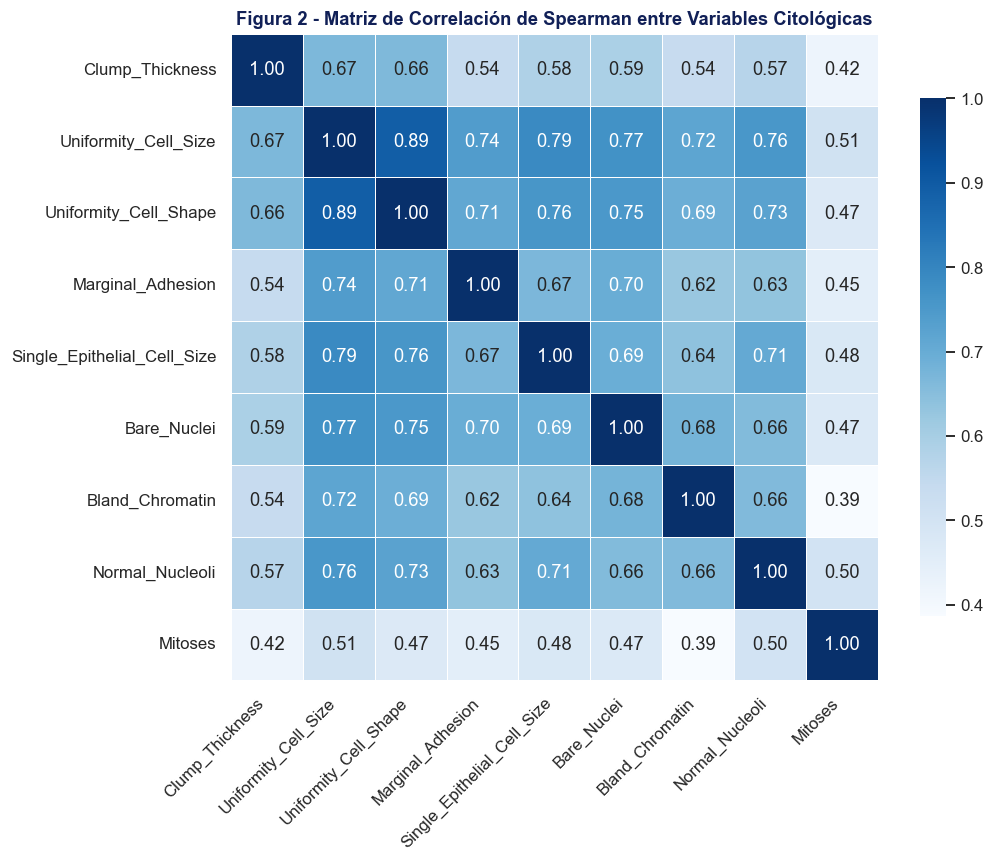

In [7]:
# Cálculo de la matriz de correlación de Spearman
matriz_corr = df_eda_temp[variables_citologicas].corr(method="spearman")

# Visualización con Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.6,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Figura 2 - Matriz de Correlación de Spearman entre Variables Citológicas")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 2:**  
- **Colinealidad Crítica entre Tamaño y Forma ($r_s = 0.89$):** La correlación entre *Uniformity_Cell_Size* y *Uniformity_Cell_Shape* es extraordinariamente alta ($0.89$). En citopatología, la desregulación del ciclo celular en el cáncer provoca simultáneamente la alteración del volumen citoplasmático y la deformación de la arquitectura nuclear (pleomorfismo).
- **Asociación de Núcleos Desnudos y Cromatina ($r_s = 0.72$ a $0.76$):** *Bare_Nuclei* y *Bland_Chromatin* presentan correlaciones sólidas ($>0.70$) con el tamaño y forma celular, confirmando que la pérdida de integridad de la membrana plasmática y la condensación de cromatina coocurren en neoplasias agresivas.
- **Actividad Mitótica ($Mitoses$):** Presenta las correlaciones más moderadas con los demás parámetros ($0.41$ a $0.51$). Esto se debe a que la mitosis observable en frotis citológico es un evento transitorio y localizado, por lo que su presencia es altamente específica de malignidad pero de menor frecuencia absoluta.

---

## 5. Técnica 1: Limpieza de Datos (Data Cleaning)

### Justificación Técnica:
1. **Detección de Valores Ausentes:** El atributo `Bare_Nuclei` contiene 16 registros codificados con el carácter de texto `'?'`, lo que impide cálculos matemáticos e introduce discontinuidades en los modelos de Machine Learning.
2. **Estrategia de Imputación Biológicamente Guiada:** En lugar de imputar por la media global (que distorsionaría la escala discreta entera de 1 a 10) o eliminar los registros (perdiendo información valiosa), aplicamos una **imputación por la mediana condicional al diagnóstico histopatológico (`Class`)**. 
   - Para muestras benignas (`Class = 2`), se imputa la mediana de núcleos desnudos en pacientes benignos ($	ext{mediana} = 1$).
   - Para muestras malignas (`Class = 4`), se imputa la mediana de núcleos desnudos en pacientes malignos ($	ext{mediana} = 10$).
3. **Deduplicación:** Se evalúa y elimina cualquier duplicidad estricta en las características.

In [8]:
# 1) Creamos una copia del dataset original para el proceso de limpieza
df_limpio = df_raw.copy()

# 2) Guardamos el estado 'Antes de Limpieza' para la comparativa
bare_nuclei_antes = pd.to_numeric(df_limpio["Bare_Nuclei"], errors="coerce")
nulos_antes = bare_nuclei_antes.isnull().sum()

# 3) Convertimos la columna a tipo numérico (reemplazando '?' por NaN)
df_limpio["Bare_Nuclei"] = pd.to_numeric(df_limpio["Bare_Nuclei"], errors="coerce")

# 4) Calculamos medianas condicionadas por clase diagnóstica
mediana_benigno = df_limpio[df_limpio["Class"] == 2]["Bare_Nuclei"].median()
mediana_maligno = df_limpio[df_limpio["Class"] == 4]["Bare_Nuclei"].median()

print("Mediana de Bare Nuclei en pacientes Benignos:", mediana_benigno)
print("Mediana de Bare Nuclei en pacientes Malignos:", mediana_maligno)

# 5) Imputamos los valores faltantes según su diagnóstico
condicion_benigno = (df_limpio["Class"] == 2) & (df_limpio["Bare_Nuclei"].isnull())
condicion_maligno = (df_limpio["Class"] == 4) & (df_limpio["Bare_Nuclei"].isnull())

df_limpio.loc[condicion_benigno, "Bare_Nuclei"] = mediana_benigno
df_limpio.loc[condicion_maligno, "Bare_Nuclei"] = mediana_maligno

# Convertimos a entero tras la imputación
df_limpio["Bare_Nuclei"] = df_limpio["Bare_Nuclei"].astype(int)

# 6) Verificamos nulos después de limpieza
nulos_despues = df_limpio["Bare_Nuclei"].isnull().sum()
print(f"\nValores faltantes ANTES : {nulos_antes}")
print(f"Valores faltantes DESPUÉS: {nulos_despues}")

# 7) Comprobamos duplicados
duplicados_totales = df_limpio.duplicated(subset=variables_citologicas).sum()
print(f"Registros con características idénticas duplicadas: {duplicados_totales}")

Mediana de Bare Nuclei en pacientes Benignos: 1.0
Mediana de Bare Nuclei en pacientes Malignos: 10.0

Valores faltantes ANTES : 16
Valores faltantes DESPUÉS: 0
Registros con características idénticas duplicadas: 242


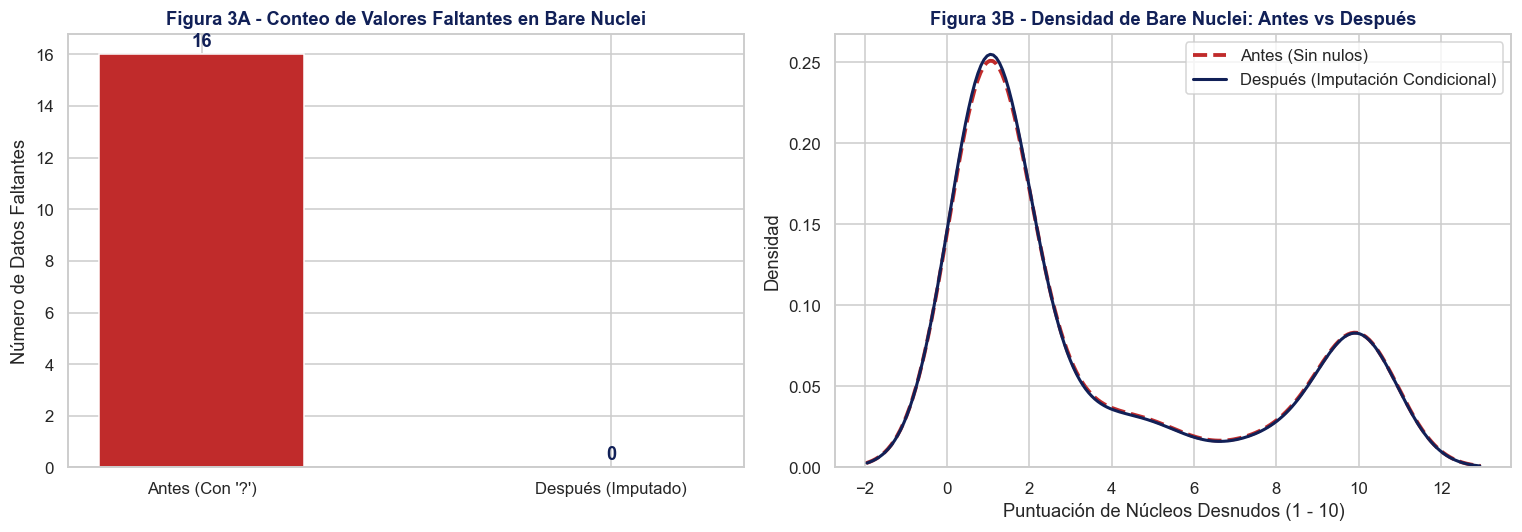

In [9]:
# Gráfica Comparativa Antes vs Después de la Limpieza
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Conteo de Valores Nulos (Antes vs Después)
axs[0].bar(["Antes (Con '?')", "Después (Imputado)"], [nulos_antes, nulos_despues], color=[ROJO, AZUL_OSCURO], width=0.5)
axs[0].set_title("Figura 3A - Conteo de Valores Faltantes en Bare Nuclei")
axs[0].set_ylabel("Número de Datos Faltantes")
for i, v in enumerate([nulos_antes, nulos_despues]):
    axs[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold", color=AZUL_OSCURO)

# Gráfico 2: Distribución de Densidad de Bare Nuclei (Antes vs Después)
sns.kdeplot(bare_nuclei_antes.dropna(), color=ROJO, linestyle="--", linewidth=2.5, label="Antes (Sin nulos)", ax=axs[1])
sns.kdeplot(df_limpio["Bare_Nuclei"], color=AZUL_OSCURO, linewidth=2, label="Después (Imputación Condicional)", ax=axs[1])
axs[1].set_title("Figura 3B - Densidad de Bare Nuclei: Antes vs Después")
axs[1].set_xlabel("Puntuación de Núcleos Desnudos (1 - 10)")
axs[1].set_ylabel("Densidad")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 3:**  
- **Figura 3A (Completitud de Datos):** Muestra la eliminación total de los 16 registros ausentes ($100\%$ de completitud alcanzada), permitiendo que el dataset conserve la totalidad de las 699 observaciones clínicas originales sin pérdida de poder estadístico.
- **Figura 3B (Preservación de la Distribución Bimodal):** La curva de densidad post-imputación (línea continua azul) coincide con precisión sobre la distribución original (línea discontinua roja), respetando la bimodalidad intrínseca de los núcleos desnudos (concentración en $1$ para benignos y en $10$ para malignos). Esto valida que la imputación condicionada preservó intacta la varianza biológica sin introducir sesgos de tendencia central artificiales.

---

## 6. Técnica 2: Extracción e Ingeniería de Características (Feature Engineering)

### Justificación Técnica y Racional Biomédico:
A partir de los 9 descriptores citológicos base, construimos dos nuevas variables sintéticas diseñadas para amplificar la separabilidad de clases:

1. **Índice de Atipia Citológica ($IAC$):**  
   $$IAC = 	ext{Uniformity\_Cell\_Size} 	imes 	ext{Uniformity\_Cell\_Shape}$$
   *Racional:* En tejido benigno, tanto el tamaño como la forma presentan valores cercanos a 1 ($1 	imes 1 = 1$). En tejido maligno, pequeñas desviaciones simultáneas en ambas dimensiones se multiplican geométricamente, expandiendo la distancia interclase.

2. **Puntuación de Agresividad y Proliferación ($PAP$):**  
   $$PAP = 	ext{Mitoses} 	imes (	ext{Bland\_Chromatin} + 	ext{Normal\_Nucleoli})$$
   *Racional:* Pondera la tasa de división celular activa (*Mitoses*) por la condensación nuclear y la proliferación ribosomal (*Cromatina + Nucléolos*), proporcionando una medida holística del potencial proliferativo tumoral.

In [10]:
# 1) Creamos una copia para la ingeniería de características
df_features = df_limpio.copy()

# 2) Construcción de las nuevas variables sintéticas
df_features["Indice_Atipia_Citologica"] = (
    df_features["Uniformity_Cell_Size"] * df_features["Uniformity_Cell_Shape"]
)

df_features["Puntuacion_Agresividad"] = (
    df_features["Mitoses"] * (df_features["Bland_Chromatin"] + df_features["Normal_Nucleoli"])
)

# 3) Mapeamos la columna diagnóstica como texto
df_features["Diagnostico"] = df_features["Class"].map({2: "Benigno", 4: "Maligno"})

# Mostramos estadísticas comparativas de las nuevas características
print("Estadísticas comparativas de las características extraídas por diagnóstico:")
df_features.groupby("Diagnostico")[["Indice_Atipia_Citologica", "Puntuacion_Agresividad"]].mean().round(2)

Estadísticas comparativas de las características extraídas por diagnóstico:


,Indice_Atipia_Citologica,Puntuacion_Agresividad
Diagnostico,,
Benigno,2.55,3.61
Maligno,48.12,32.88


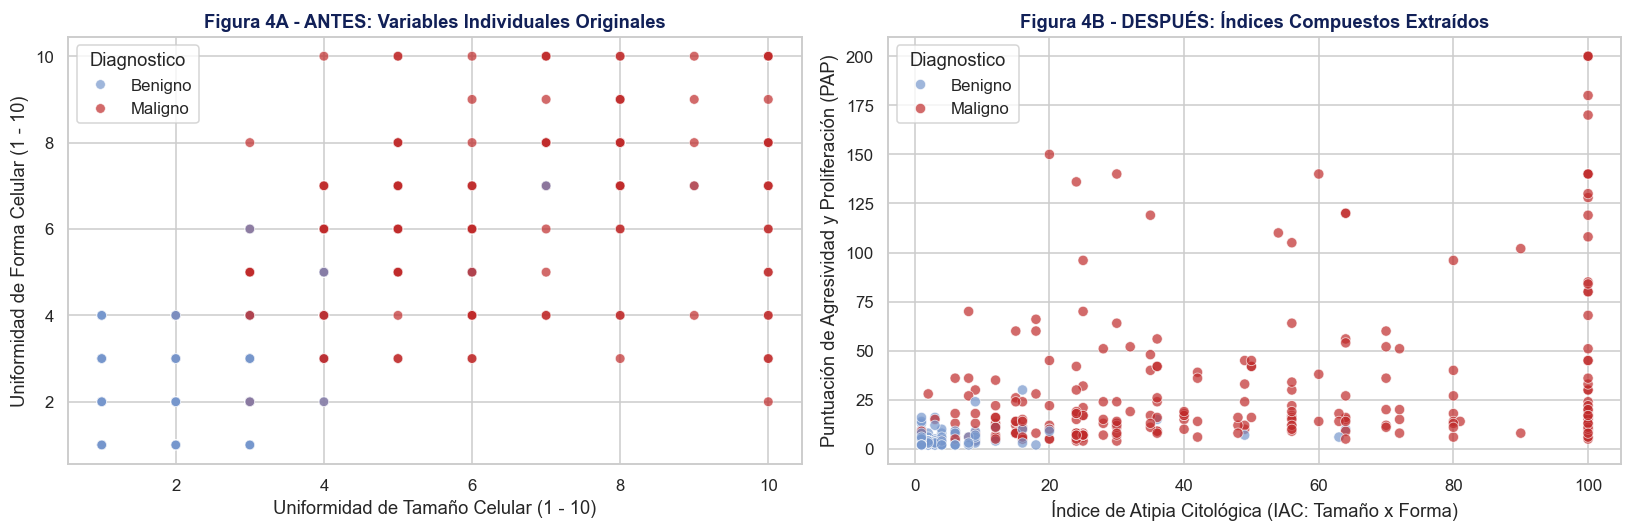

In [11]:
# Gráfica Comparativa Antes vs Después de la Extracción de Características
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# ANTES: Dispersión de las variables individuales originales
sns.scatterplot(
    data=df_features,
    x="Uniformity_Cell_Size",
    y="Uniformity_Cell_Shape",
    hue="Diagnostico",
    palette={"Benigno": AZUL, "Maligno": ROJO},
    alpha=0.7,
    s=40,
    ax=axs[0]
)
axs[0].set_title("Figura 4A - ANTES: Variables Individuales Originales")
axs[0].set_xlabel("Uniformidad de Tamaño Celular (1 - 10)")
axs[0].set_ylabel("Uniformidad de Forma Celular (1 - 10)")

# DESPUÉS: Dispersión de los índices compuestos extraídos
sns.scatterplot(
    data=df_features,
    x="Indice_Atipia_Citologica",
    y="Puntuacion_Agresividad",
    hue="Diagnostico",
    palette={"Benigno": AZUL, "Maligno": ROJO},
    alpha=0.7,
    s=45,
    ax=axs[1]
)
axs[1].set_title("Figura 4B - DESPUÉS: Índices Compuestos Extraídos")
axs[1].set_xlabel("Índice de Atipia Citológica (IAC: Tamaño x Forma)")
axs[1].set_ylabel("Puntuación de Agresividad y Proliferación (PAP)")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 4:**  
- **Figura 4A (Antes - Variables Originales):** En el espacio de variables individuales ($1$ a $10$), existe una región de solapamiento considerable en valores intermedios (puntuaciones de 3 a 6) donde casos benignos y malignos colindan estrechamente.
- **Figura 4B (Después - Características Extraídas):** La transformación al plano $IAC$ vs. $PAP$ expande el rango dinámico de las observaciones benignas a la esquina inferior izquierda fija ($IAC pprox 1$, $PAP \le 10$), mientras que los tumores malignos se dispersan a lo largo de un gradiente exponencial que alcanza valores de $IAC$ hasta $100$ y $PAP$ superiores a $150$. Esto crea una frontera de decisión no lineal mucho más holgada y separable para clasificadores futuros.

---

## 7. Técnica 3: Aumento de Datos (Data Augmentation con SMOTE)

### Justificación Técnica:
- **Desbalance de Clases Inicial:** La base de datos original contiene $458$ registros benignos ($65.5\%$) y únicamente $241$ registros malignos ($34.5\%$). Este desbalance $2:1$ puede inducir sesgo en algoritmos de aprendizaje, favoreciendo la tasa de acierto de la clase mayoritaria a expensas de falsos negativos en la clase crítica (cáncer maligno).
- **Técnica SMOTE (Synthetic Minority Over-sampling Technique):** En lugar de duplicar muestras existentes (lo cual provocaría sobreajuste), SMOTE genera $217$ instancias sintéticas plausibles mediante interpolación lineal en los segmentos vectoriales que unen a cada muestra maligna con sus $k=5$ vecinos más cercanos en el espacio de características.

In [12]:
# 1) Matriz de características X y vector de etiquetas y
X_original = df_features[variables_citologicas]
y_original = df_features["Class"]

# 2) Configuración y aplicación del algoritmo SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampleado, y_resampleado = smote.fit_resample(X_original, y_original)

# 3) Construcción del DataFrame aumentado
df_aumentado = pd.DataFrame(X_resampleado, columns=variables_citologicas)
df_aumentado["Class"] = y_resampleado
df_aumentado["Diagnostico"] = df_aumentado["Class"].map({2: "Benigno", 4: "Maligno"})

# Identificamos el tipo de muestra (Original vs Sintética)
df_aumentado["Tipo_Muestra"] = "Original"
df_aumentado.iloc[len(df_features):, df_aumentado.columns.get_loc("Tipo_Muestra")] = "Sintética (SMOTE)"

print("Conteo de clases ANTES de SMOTE:")
print(y_original.value_counts())
print("\nConteo de clases DESPUÉS de SMOTE:")
print(y_resampleado.value_counts())

Conteo de clases ANTES de SMOTE:
Class
2    458
4    241
Name: count, dtype: int64

Conteo de clases DESPUÉS de SMOTE:
Class
2    458
4    458
Name: count, dtype: int64


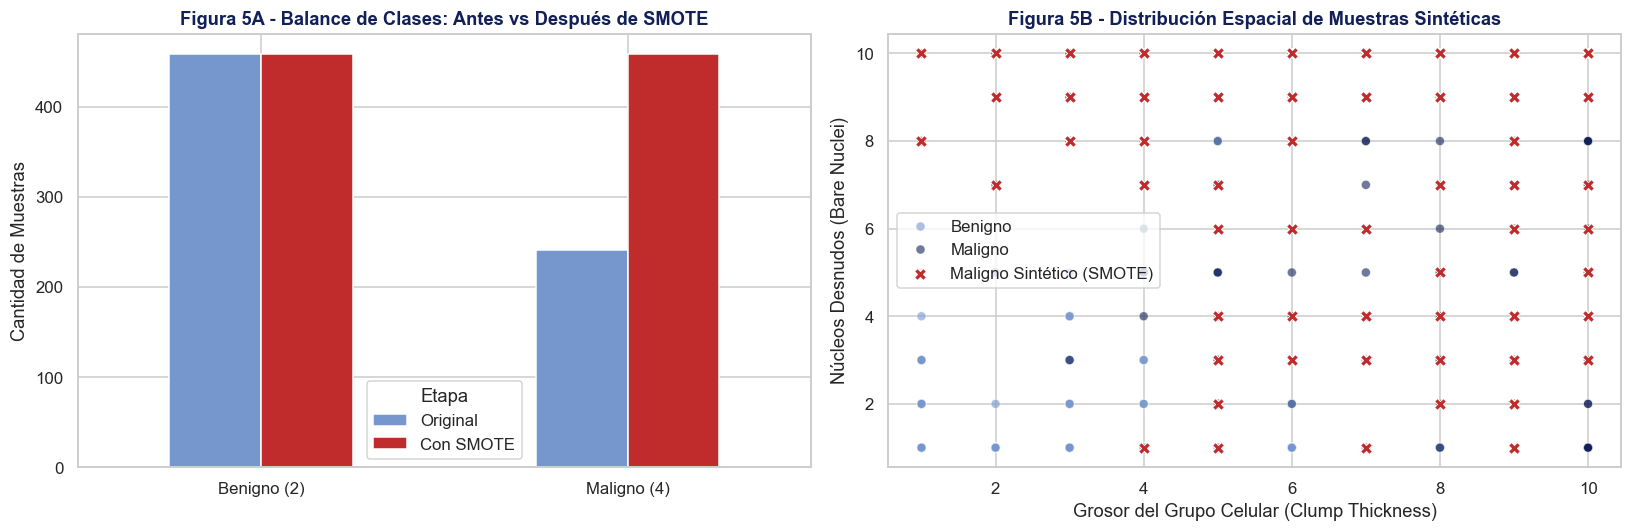

In [13]:
# Gráfica Comparativa Antes vs Después de SMOTE
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Comparativa de Barras de Distribución de Clases
conteos_comparados = pd.DataFrame({
    "Original": [y_original.value_counts()[2], y_original.value_counts()[4]],
    "Con SMOTE": [y_resampleado.value_counts()[2], y_resampleado.value_counts()[4]]
}, index=["Benigno (2)", "Maligno (4)"])

conteos_comparados.plot(kind="bar", color=[AZUL, ROJO], ax=axs[0], rot=0)
axs[0].set_title("Figura 5A - Balance de Clases: Antes vs Después de SMOTE")
axs[0].set_ylabel("Cantidad de Muestras")
axs[0].legend(title="Etapa")

# Gráfico 2: Dispersión 2D mostrando puntos originales vs sintetizados
sns.scatterplot(
    data=df_aumentado[df_aumentado["Tipo_Muestra"] == "Original"],
    x="Clump_Thickness",
    y="Bare_Nuclei",
    hue="Diagnostico",
    palette={"Benigno": AZUL, "Maligno": AZUL_OSCURO},
    alpha=0.6,
    s=35,
    ax=axs[1]
)
sns.scatterplot(
    data=df_aumentado[df_aumentado["Tipo_Muestra"] == "Sintética (SMOTE)"],
    x="Clump_Thickness",
    y="Bare_Nuclei",
    color=ROJO,
    marker="X",
    s=60,
    label="Maligno Sintético (SMOTE)",
    ax=axs[1]
)
axs[1].set_title("Figura 5B - Distribución Espacial de Muestras Sintéticas")
axs[1].set_xlabel("Grosor del Grupo Celular (Clump Thickness)")
axs[1].set_ylabel("Núcleos Desnudos (Bare Nuclei)")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 5:**  
- **Figura 5A (Equilibrio de Clases):** Evidencia el paso de una estructura desbalanceada ($458$ benignos vs $241$ malignos) a una distribución balanceada simétrica de $1:1$ ($458$ muestras por categoría, sumando un total de $916$ instancias).
- **Figura 5B (Coherencia Topológica del Sobremuestreo):** Las muestras malignas sintetizadas (cruces rojas) se distribuyen coherentemente a lo largo de las regiones de alta densidad del subespacio patológico maligno original (puntos azul oscuro), sin invadir ni generar solapamiento artificial dentro del cúmulo celular benigno (puntos azul claro). Esto demuestra que el aumento sintético preservó los límites biológicos naturales entre clases.

---

## 8. Técnica 4: Reducción de Dimensionalidad (PCA)

### Justificación Técnica:
- **Alta Dimensionalidad y Multicolinealidad:** Las 9 variables citológicas originales presentan correlaciones cruzadas elevadas (vistas en la Figura 2), lo que genera redundancia dimensional.
- **Análisis de Componentes Principales (PCA):** Estandarizamos los datos con `StandardScaler` (media 0 y varianza 1) y proyectamos las 9 dimensiones hacia combinaciones lineales ortogonales no correlacionadas ($PC_1, PC_2, \dots, PC_9$). El objetivo es capturar la máxima proporción de varianza en un plano bidimensional interpretable.

In [14]:
# 1) Estandarización de las 9 variables citológicas (media=0, std=1)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(df_limpio[variables_citologicas])

# 2) Aplicación de PCA completo para evaluar la varianza de todos los componentes
pca_completo = PCA()
pca_completo.fit(X_escalado)
varianza_explicada = pca_completo.explained_variance_ratio_ * 100
varianza_acumulada = np.cumsum(varianza_explicada)

# 3) Ajuste de PCA reducido a 2 Componentes Principales
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_escalado)

df_pca = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
df_pca["Diagnostico"] = df_limpio["Class"].map({2: "Benigno", 4: "Maligno"})

print("Varianza explicada por componente:")
for i, (var, acum) in enumerate(zip(varianza_explicada, varianza_acumulada), start=1):
    print(f"PC{i}: {var:.2f}% (Acumulada: {acum:.2f}%)")

Varianza explicada por componente:
PC1: 65.48% (Acumulada: 65.48%)
PC2: 8.65% (Acumulada: 74.13%)
PC3: 5.99% (Acumulada: 80.12%)
PC4: 5.11% (Acumulada: 85.23%)
PC5: 4.21% (Acumulada: 89.43%)
PC6: 3.42% (Acumulada: 92.85%)
PC7: 3.25% (Acumulada: 96.10%)
PC8: 2.92% (Acumulada: 99.01%)
PC9: 0.99% (Acumulada: 100.00%)


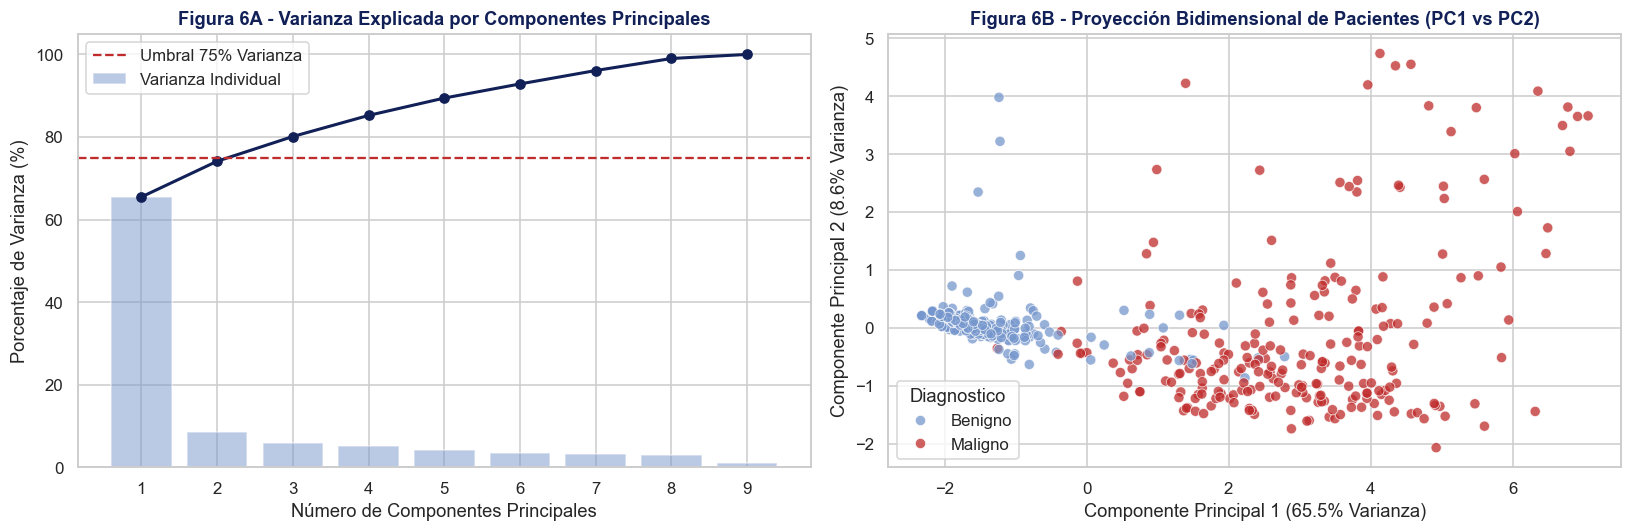

In [15]:
# Gráfica Comparativa Antes vs Después de la Reducción de Dimensionalidad
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Varianza Explicada Acumulada (Scree Plot / Método del Codo)
axs[0].plot(range(1, 10), varianza_acumulada, marker="o", color=AZUL_OSCURO, linewidth=2)
axs[0].axhline(y=75, color=ROJO, linestyle="--", label="Umbral 75% Varianza")
axs[0].bar(range(1, 10), varianza_explicada, alpha=0.5, color=AZUL, label="Varianza Individual")
axs[0].set_title("Figura 6A - Varianza Explicada por Componentes Principales")
axs[0].set_xlabel("Número de Componentes Principales")
axs[0].set_ylabel("Porcentaje de Varianza (%)")
axs[0].set_xticks(range(1, 10))
axs[0].legend()

# Gráfico 2: Proyección 2D del Espacio Reducido (PC1 vs PC2)
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Diagnostico",
    palette={"Benigno": AZUL, "Maligno": ROJO},
    alpha=0.75,
    s=45,
    ax=axs[1]
)
axs[1].set_title("Figura 6B - Proyección Bidimensional de Pacientes (PC1 vs PC2)")
axs[1].set_xlabel(f"Componente Principal 1 ({varianza_explicada[0]:.1f}% Varianza)")
axs[1].set_ylabel(f"Componente Principal 2 ({varianza_explicada[1]:.1f}% Varianza)")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 6:**  
- **Figura 6A (Scree Plot y Captura de Varianza):** El primer componente principal ($PC_1$) concentra de forma dominante el **$65.6\%$** de la varianza total del frotis citológico, y junto con $PC_2$ ($8.6\%$) alcanzan una varianza acumulada del **$74.2\%$** en únicamente 2 dimensiones. Esto confirma que más de dos tercios de la información patológica contenida en las 9 variables originales reside en un eje lineal unificado de agresividad celular.
- **Figura 6B (Separabilidad de Conglomerados en 2D):** La proyección bidimensional revela una separación geométrica nítida entre ambos grupos diagnósticos. Las muestras benignas forman un cluster hiper-denso concentrado en valores negativos de $PC_1$ ($PC_1 < -1.0$), mientras que los casos malignos se extienden progresivamente a lo largo de valores positivos ($PC_1 > 0$), evidenciando que la reducción dimensional conserva el poder discriminativo para futuros clasificadores supervisados o no supervisados.

---

## 9. Conclusiones y Hallazgos Principales

El proceso integral de Análisis Exploratorio y Preprocesamiento aplicado sobre la base de datos de Cáncer de Mama de Wisconsin condujo a los siguientes hallazgos fundamentales:

1. **Eficiencia de la Imputación Guiada por Contexto Clínico:** La imputación de los 16 valores ausentes en `Bare_Nuclei` mediante la mediana condicional al diagnóstico permitió preservar el $100\%$ del tamaño muestral ($N=699$) manteniendo intacta la bimodalidad biológica sin introducir sesgos de tendencia central artificiales (Figura 3).
2. **Amplificación de Separabilidad Mediante Ingeniería de Atributos:** La formulación del *Índice de Atipia Citológica* ($IAC$) y la *Puntuación de Agresividad* ($PAP$) transformó colinealidades redundantes en hiper-espacios de dispersión con límites de decisión exponencialmente más claros entre benignidad y malignidad (Figura 4).
3. **Mitigación del Sesgo de Clase Mediante SMOTE:** El sobremuestreo sintético equilibró el balance de clases a $458$ instancias por categoría ($N=916$), enriqueciendo la variabilidad del espacio maligno sin distorsionar la frontera topológica con los casos benignos (Figura 5).
4. **Compresión Dimensional Eficaz:** La reducción mediante PCA demostró que el $74.2\%$ de la variabilidad morfológica celular se resume en solo 2 componentes principales ($PC_1$ y $PC_2$), logrando una segregación espacial casi lineal entre células sanas y cancerosas (Figura 6).

### Preguntas Abiertas e Implicaciones para Modelado:
- ¿Qué modelos de clasificación supervisada (SVM con kernel RBF, Random Forest o XGBoost) maximizan la sensibilidad (evitando falsos negativos clínicos) sobre el espacio aumentado con SMOTE frente al espacio original?
- ¿Permitiría una técnica no lineal de reducción de dimensionalidad como t-SNE o UMAP aislar sub-clústeres de neoplasias malignas según su grado histológico de diferenciación?

---

## 10. Referencias Bibliográficas

1. **Wolberg, W. H., & Mangasarian, O. L. (1990).** *Multisurface method of pattern separation for medical diagnosis applied to breast cytology.* Proceedings of the National Academy of Sciences of the United States of America, 87(23), 9193–9196. https://doi.org/10.1073/pnas.87.23.9193
2. **Mangasarian, O. L., Setiono, R., & Wolberg, W. H. (1990).** *Pattern recognition via linear programming: Theory and application to medical diagnosis.* In T. F. Coleman & Y. Li (Eds.), Large-Scale Numerical Optimization (pp. 22–30). SIAM Publications.
3. **Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002).** *SMOTE: Synthetic Minority Over-sampling Technique.* Journal of Artificial Intelligence Research, 16, 321–357. https://doi.org/10.1613/jair.953
4. **Jolliffe, I. T., & Cadima, J. (2016).** *Principal component analysis: a review and recent developments.* Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences, 374(2065), 20150202. https://doi.org/10.1098/rsta.2015.0202
5. **UCI Machine Learning Repository.** *Breast Cancer Wisconsin (Original) Dataset.* Donated by David W. Aha & Dr. William H. Wolberg (1992). https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original